In [13]:
from Lim_solver import smart_optimise
from neumann_rates import raw_overpass, raw_overpass_instant
import numpy as np
import matplotlib.pyplot as plt 
from tqdm import tqdm

# compare annual keys for micius and qeyssat


In [14]:
prob = lambda phi,R,h:(-1+R/(R+h)*np.sin(phi)/np.sqrt(1-(R*np.cos(phi)/(R+h))**2)) / (np.pi/3 - 2*np.acos(np.sqrt(3)*R/(R+h)/2))
angle_range=np.arange(15, 170,5)
rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
loss_profiles = [np.loadtxt(f"15deg_500000m_0m_0.25m/Loss_maxelev_{angle}degrees.csv",skiprows=1,delimiter=",")  if angle<=90 else np.loadtxt(f"15deg_500000m_0m_0.25m/Loss_maxelev_{180-angle}degrees.csv",skiprows=1,delimiter=",") for angle in angle_range]
h=500
annual_factor=359.4

In [7]:
# compare optimised cutoff for integrated and overpass-by-overpass annual skl
powers=np.linspace(5,10,6)
cutoff_angles = np.arange(20, 30,step=1)
rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
# with 10km fibre
skl_sbs = []
skl_int = []
for cutoff in cutoff_angles:
    for power in tqdm(powers):
        params = [9.47893858965945, 9.89101987420694, 0.037228590019520497, 0.03834132110856429, 6135831.8248959305*power, 1e-09]        
        # generate an annual key for this cutoff and power by integrating over the angles
        skls = []
        ms = []
        qbers = []
        for i,prof in enumerate(loss_profiles):
            loss= prof[prof[:,3]>=cutoff,1]+prof[prof[:,3]>=cutoff,2]+1.26579805859825
            qber, qx, m = raw_overpass(params, loss)
            delta = (qber+qx)/2
            m/=2 # sifting!
            skls.append(smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m)
            ms.append(m)
            qbers.append(delta)

        skl_sbs.append(np.trapezoid(np.nan_to_num(np.array(skls))*prob(rad_angles,3575,h), rad_angles) * annual_factor)
        

        ms = np.nan_to_num(np.array(ms))
        qbers = np.nan_to_num(np.array(qbers))
        m = np.trapezoid(ms*prob(rad_angles,3575,h), rad_angles)* annual_factor
        delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,h), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,h), rad_angles)
        skl_int.append(smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m)



100%|██████████| 6/6 [01:17<00:00, 12.84s/it]


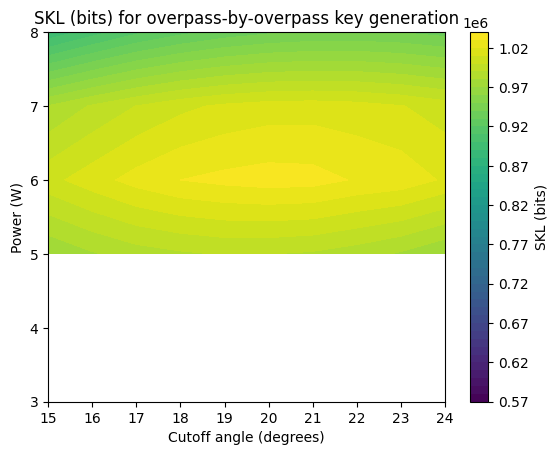

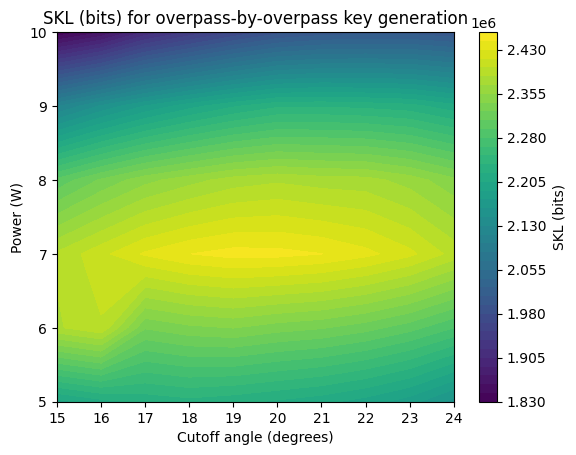

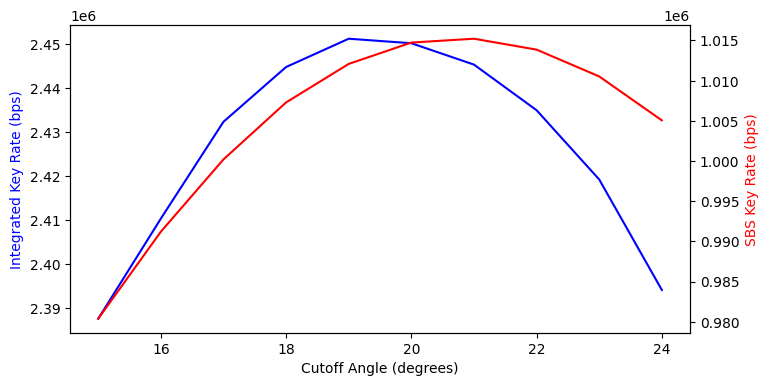

In [16]:
plt.contourf(*np.meshgrid(cutoff_angles, powers), np.reshape(skl_sbs, (len(cutoff_angles), len(powers))).T, levels=50)
plt.xlabel("Cutoff angle (degrees)")
plt.ylabel("Power (W)")
plt.title("SKL (bits) for overpass-by-overpass key generation")
plt.colorbar(label="SKL (bits)")
plt.ylim(3, 8)
plt.show()

plt.contourf(*np.meshgrid(cutoff_angles, powers), np.reshape(skl_int, (len(cutoff_angles), len(powers))).T, levels=50)
plt.xlabel("Cutoff angle (degrees)")
plt.ylabel("Power (W)")
plt.title("SKL (bits) for overpass-by-overpass key generation")
plt.colorbar(label="SKL (bits)")
plt.show()
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(cutoff_angles,np.reshape(skl_int, (len(cutoff_angles), len(powers))).T[2,:],color="blue", label="integrated")
ax2.plot(cutoff_angles,np.reshape(skl_sbs, (len(cutoff_angles), len(powers))).T[2,:], color="red", label="sbs")
ax1.set_xlabel("Cutoff Angle (degrees)")
ax1.set_ylabel("Integrated Key Rate (bps)", color="blue")
ax2.set_ylabel("SBS Key Rate (bps)", color="red")
plt.show()

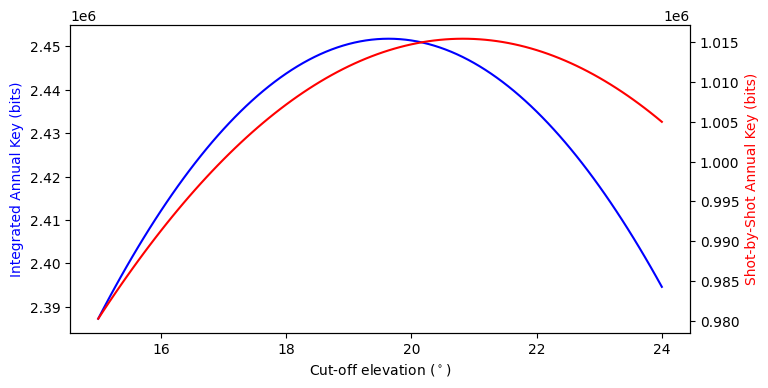

In [29]:
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
smooth_x=np.linspace(cutoff_angles[0], cutoff_angles[-1], 100)
from scipy.optimize import curve_fit
obj=lambda x,a,b,c: a*x**2+b*x+c
# ax1.plot(cutoff_angles,np.reshape(skl_int, (len(cutoff_angles), len(powers))).T[2,:],color="blue", label="integrated")
popt,cov=curve_fit(obj, cutoff_angles, np.reshape(skl_int, (len(cutoff_angles), len(powers))).T[2,:])
ax1.plot(smooth_x, obj(smooth_x, *popt), color="blue", label="integrated fit")
# ax2.plot(cutoff_angles,np.reshape(skl_sbs, (len(cutoff_angles), len(powers))).T[2,:], color="red", label="sbs")
popt,cov=curve_fit(obj, cutoff_angles, np.reshape(skl_sbs, (len(cutoff_angles), len(powers))).T[2,:])
ax2.plot(smooth_x, obj(smooth_x, *popt), color="red", label="sbs fit")
ax1.set_xlabel(r"Cut-off elevation ($^\circ$)")
ax1.set_ylabel("Integrated Annual Key (bits)", color="blue")
ax2.set_ylabel("Shot-by-Shot Annual Key (bits)", color="red")
plt.savefig("cutoff_comparison.pdf", dpi=300)

In [11]:
# compare optimised cutoff for integrated and overpass-by-overpass annual skl
cutoff_angles = np.arange(15, 25,step=1)
rad_angles = np.linspace(np.pi/6,5*np.pi/6,len(angle_range))
# with 0km fibre
skl_sbs_0 = []
skl_int_0 = []
for cutoff in cutoff_angles:
    for power in tqdm(powers):
        params = [7.761328918344407, 7.542259886343475, 0.0335677812551474, 0.02531375770896907, 10826895.017621633*power, 4e-10]
        # generate an annual key for this cutoff and power by integrating over the angles
        skls = []
        ms = []
        qbers = []
        for i,prof in enumerate(loss_profiles):
            loss= prof[prof[:,3]>=cutoff,1]+prof[prof[:,3]>=cutoff,2]+1.26579805859825
            qber, qx, m = raw_overpass(params, loss)
            delta = (qber+qx)/2
            m/=2 # sifting!
            skls.append(smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m)
            ms.append(m)
            qbers.append(delta)

        skl_sbs_0.append(np.trapezoid(np.nan_to_num(np.array(skls))*prob(rad_angles,3575,h), rad_angles) * annual_factor)
        

        ms = np.nan_to_num(np.array(ms))
        qbers = np.nan_to_num(np.array(qbers))
        m = np.trapezoid(ms*prob(rad_angles,3575,h), rad_angles)* annual_factor
        delta = np.trapezoid(np.array(qbers)*ms*prob(rad_angles,3575,h), rad_angles) / np.trapezoid(ms*prob(rad_angles,3575,h), rad_angles)
        skl_int_0.append(smart_optimise(m, delta, eps_qkd=1e-6, t=np.log2(10**8), f=1.19) * m)



100%|██████████| 6/6 [01:30<00:00, 15.13s/it]


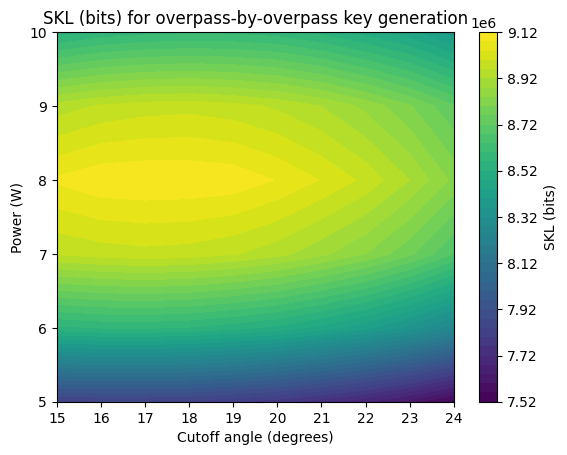

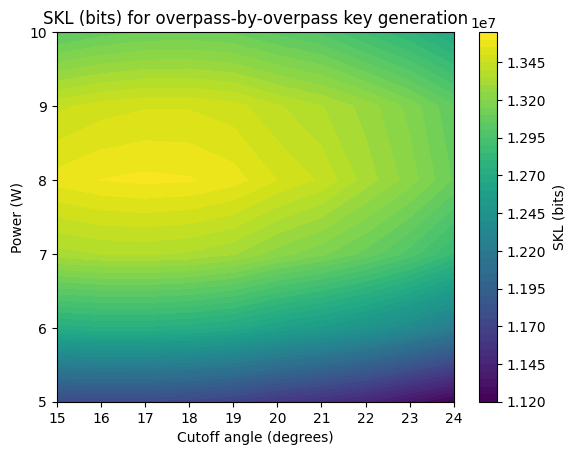

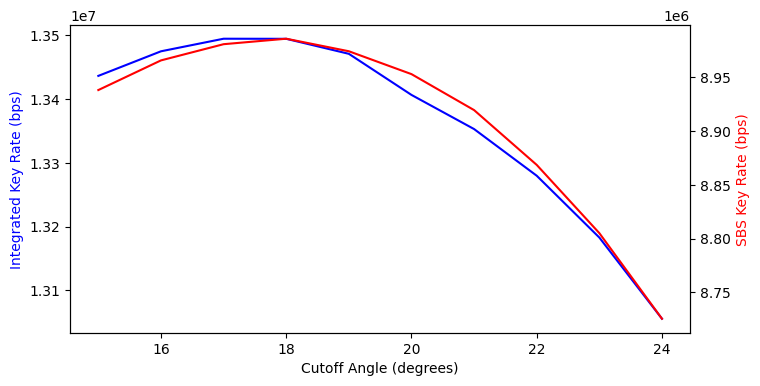

In [12]:
plt.contourf(*np.meshgrid(cutoff_angles, powers), np.reshape(skl_sbs_0, (len(cutoff_angles), len(powers))).T, levels=50)
plt.xlabel("Cutoff angle (degrees)")
plt.ylabel("Power (W)")
plt.title("SKL (bits) for overpass-by-overpass key generation")
plt.colorbar(label="SKL (bits)")
plt.show()

plt.contourf(*np.meshgrid(cutoff_angles, powers), np.reshape(skl_int_0, (len(cutoff_angles), len(powers))).T, levels=50)
plt.xlabel("Cutoff angle (degrees)")
plt.ylabel("Power (W)")
plt.title("SKL (bits) for overpass-by-overpass key generation")
plt.colorbar(label="SKL (bits)")
plt.show()
f, ax1  = plt.subplots(1, 1, figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(cutoff_angles,np.reshape(skl_int_0, (len(cutoff_angles), len(powers))).T[4,:],color="blue", label="integrated")
ax2.plot(cutoff_angles,np.reshape(skl_sbs_0, (len(cutoff_angles), len(powers))).T[4,:], color="red", label="sbs")
ax1.set_xlabel("Cutoff Angle (degrees)")
ax1.set_ylabel("Integrated Key Rate (bps)", color="blue")
ax2.set_ylabel("SBS Key Rate (bps)", color="red")
plt.show()